 # EmoLearn: Multimodal Affect Recognition for Online Learning
 ## Final Project — Improved F1 with Binary Classification, Focal Loss, and Oversampling

 **Author:** Rui Wu
 **Course:** CS466

 Improvements over Check-In 2:
 1. Frame-level features for LSTM/GRU temporal modeling
 2. Binary classification (Low vs High) — matches DAiSEE paper
 3. Focal loss for class imbalance
 4. Oversampling minority class
 5. Comprehensive LSTM vs GRU comparison
 6. Attention-based fusion

 ## 1. Setup

In [ ]:
import os, cv2, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

if torch.backends.mps.is_available():
    device = torch.device("mps"); print("Using Apple M4 GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda"); print("Using CUDA GPU")
else:
    device = torch.device("cpu"); print("Using CPU")

DAISEE_ROOT = "/Users/apple/Desktop/DAiSEE"
DATA_DIR = os.path.join(DAISEE_ROOT, "DataSet")
LABEL_DIR = os.path.join(DAISEE_ROOT, "Labels")
FEATURE_DIR = os.path.join(DAISEE_ROOT, "Features")
os.makedirs(FEATURE_DIR, exist_ok=True)

import mediapipe as mp
import urllib.request
BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

FACE_DETECTOR_MODEL = "blaze_face_short_range.tflite"
FACE_LANDMARKER_MODEL = "face_landmarker.task"
for fname, url in [
    (FACE_DETECTOR_MODEL, "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"),
    (FACE_LANDMARKER_MODEL, "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"),
]:
    if not os.path.exists(fname):
        print(f"Downloading {fname}..."); urllib.request.urlretrieve(url, fname)

NUM_FRAMES = 10; BATCH_SIZE = 32; LEARNING_RATE = 1e-3; NUM_EPOCHS = 30
RESNET_DIM = 512; GEOM_DIM = 6

train_labels = pd.read_csv(os.path.join(LABEL_DIR, "TrainLabels.csv"))
val_labels = pd.read_csv(os.path.join(LABEL_DIR, "ValidationLabels.csv"))
test_labels = pd.read_csv(os.path.join(LABEL_DIR, "TestLabels.csv"))
FRUS_COL = "Frustration " if "Frustration " in train_labels.columns else "Frustration"
print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")

Using Apple M4 GPU (MPS)
Train: 5358, Val: 1429, Test: 1784


 ## 2. Feature Extraction

In [ ]:
def get_video_path(clip_id, data_dir, split="Train"):
    if "/" in clip_id or "\\" in clip_id:
        return os.path.join(data_dir, split, clip_id)
    clip_name = clip_id.replace(".avi", "")
    return os.path.join(data_dir, split, clip_name[:6], clip_name, clip_name + ".avi")

def extract_frames(video_path, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0: cap.release(); return []
    indices = np.linspace(0, total-1, min(num_frames, total), dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret: frames.append(frame)
    cap.release()
    return frames

POSE_LANDMARKS = [1, 33, 263, 61, 291, 199]
LEFT_EYE = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
MOUTH = [61, 291, 0, 17]

def compute_geometric(landmarks, w, h):
    def ear(idx):
        pts = [(landmarks[i].x*w, landmarks[i].y*h) for i in idx]
        v1 = np.linalg.norm(np.array(pts[1])-np.array(pts[5]))
        v2 = np.linalg.norm(np.array(pts[2])-np.array(pts[4]))
        hz = np.linalg.norm(np.array(pts[0])-np.array(pts[3]))
        return (v1+v2)/(2.0*hz) if hz>0 else 0.0
    def mar():
        pts = [(landmarks[i].x*w, landmarks[i].y*h) for i in MOUTH]
        return np.linalg.norm(np.array(pts[2])-np.array(pts[3])) / max(np.linalg.norm(np.array(pts[0])-np.array(pts[1])), 1e-6)
    model_pts = np.array([(0,0,0),(-225,170,-135),(225,170,-135),(-150,-150,-125),(150,-150,-125),(0,-330,-65)], dtype=np.float64)
    img_pts = np.array([(landmarks[i].x*w, landmarks[i].y*h) for i in POSE_LANDMARKS], dtype=np.float64)
    cam = np.array([[w,0,w/2],[0,w,h/2],[0,0,1]], dtype=np.float64)
    ok, rvec, tvec = cv2.solvePnP(model_pts, img_pts, cam, np.zeros((4,1)), flags=cv2.SOLVEPNP_ITERATIVE)
    if not ok: return [0.0]*6
    rmat,_ = cv2.Rodrigues(rvec)
    _,_,_,_,_,_,euler = cv2.decomposeProjectionMatrix(np.vstack([np.hstack([rmat,tvec]),[0,0,0,1]])[:3,:])
    return [euler[0,0], euler[1,0], euler[2,0], ear(LEFT_EYE), ear(RIGHT_EYE), mar()]

def extract_sequence_features(label_df, data_dir, split_name, feature_dir, resnet, transform, face_det, face_lm):
    app_path = os.path.join(feature_dir, f"{split_name}_appearance_seq.npy")
    geo_path = os.path.join(feature_dir, f"{split_name}_geometric_seq.npy")
    lbl_path = os.path.join(feature_dir, f"{split_name}_labels_seq.npy")
    if all(os.path.exists(p) for p in [app_path, geo_path, lbl_path]):
        print(f"{split_name}: Loading from cache...")
        return np.load(app_path), np.load(geo_path), np.load(lbl_path)
    print(f"{split_name}: Extracting from {len(label_df)} videos...")
    all_app, all_geo, all_lbl = [], [], []
    start = time.time()
    for i in range(len(label_df)):
        row = label_df.iloc[i]
        vpath = get_video_path(row["ClipID"], data_dir, split=split_name)
        if not os.path.exists(vpath): continue
        frames = extract_frames(vpath, NUM_FRAMES)
        if not frames: continue
        fa, fg = [], []
        for frame in frames:
            h,w,_ = frame.shape; rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            det = face_det.detect(mp_img)
            if det.detections:
                bb = det.detections[0].bounding_box
                x1,y1 = max(0,bb.origin_x-int(bb.width*0.1)), max(0,bb.origin_y-int(bb.height*0.1))
                x2,y2 = min(w,bb.origin_x+bb.width+int(bb.width*0.1)), min(h,bb.origin_y+bb.height+int(bb.height*0.1))
                crop = rgb[y1:y2,x1:x2]
                crop = cv2.resize(crop,(224,224)) if crop.size>0 else np.zeros((224,224,3),dtype=np.uint8)
            else: crop = cv2.resize(rgb,(224,224))
            with torch.no_grad(): fa.append(resnet(transform(crop).unsqueeze(0)).squeeze().numpy())
            lm = face_lm.detect(mp_img)
            fg.append(compute_geometric(lm.face_landmarks[0],w,h) if lm.face_landmarks else [0.0]*GEOM_DIM)
        while len(fa)<NUM_FRAMES: fa.append(np.zeros(RESNET_DIM,dtype=np.float32)); fg.append([0.0]*GEOM_DIM)
        all_app.append(np.array(fa[:NUM_FRAMES])); all_geo.append(np.array(fg[:NUM_FRAMES]))
        all_lbl.append([row["Boredom"],row["Engagement"],row["Confusion"],row[FRUS_COL]])
        if (i+1)%200==0:
            r=(i+1)/(time.time()-start); print(f"  {i+1}/{len(label_df)} ({r:.1f} v/s, ~{(len(label_df)-i-1)/r/60:.0f}m left)")
    all_app=np.array(all_app,dtype=np.float32); all_geo=np.array(all_geo,dtype=np.float32); all_lbl=np.array(all_lbl,dtype=np.int64)
    np.save(app_path,all_app); np.save(geo_path,all_geo); np.save(lbl_path,all_lbl)
    print(f"  Done: {len(all_app)} videos in {(time.time()-start)/60:.1f} min")
    return all_app, all_geo, all_lbl

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT); resnet.fc=nn.Identity(); resnet.eval()
transform = transforms.Compose([transforms.ToPILImage(),transforms.Resize((224,224)),transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
face_det = FaceDetector.create_from_options(FaceDetectorOptions(base_options=BaseOptions(model_asset_path=FACE_DETECTOR_MODEL),running_mode=VisionRunningMode.IMAGE,min_detection_confidence=0.5))
face_lm = FaceLandmarker.create_from_options(FaceLandmarkerOptions(base_options=BaseOptions(model_asset_path=FACE_LANDMARKER_MODEL),running_mode=VisionRunningMode.IMAGE,num_faces=1))

train_app,train_geo,train_lbl = extract_sequence_features(train_labels,DATA_DIR,"Train",FEATURE_DIR,resnet,transform,face_det,face_lm)
val_app,val_geo,val_lbl = extract_sequence_features(val_labels,DATA_DIR,"Validation",FEATURE_DIR,resnet,transform,face_det,face_lm)
test_app,test_geo,test_lbl = extract_sequence_features(test_labels,DATA_DIR,"Test",FEATURE_DIR,resnet,transform,face_det,face_lm)
face_det.close(); face_lm.close()
print(f"\nTrain: {train_app.shape}, Val: {val_app.shape}, Test: {test_app.shape}")

Train: Loading from cache...
Validation: Loading from cache...
Test: Loading from cache...

Train: (4852, 10, 512), Val: (1429, 10, 512), Test: (1638, 10, 512)


I0000 00:00:1777346141.734914 46102780 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777346141.740913 46102781 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777346141.742619 46102812 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1777346141.748994 46102812 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1777346141.750155 46102820 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777346141.757237 46102820 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


 ## 3. Dataset — 4-Class and Binary

In [ ]:
TARGET_COL = 1

class DAiSEEDataset(Dataset):
    def __init__(self, app, geo, labels, target_col=1, binary=False):
        self.app = torch.tensor(app, dtype=torch.float32)
        self.geo = torch.tensor(geo, dtype=torch.float32)
        raw = labels[:, target_col]
        self.labels = torch.tensor((raw>=2).astype(np.int64) if binary else raw, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.app[idx], self.geo[idx], self.labels[idx]

def make_loaders(binary=False, oversample=False):
    train_ds = DAiSEEDataset(train_app,train_geo,train_lbl,TARGET_COL,binary)
    val_ds = DAiSEEDataset(val_app,val_geo,val_lbl,TARGET_COL,binary)
    test_ds = DAiSEEDataset(test_app,test_geo,test_lbl,TARGET_COL,binary)
    if oversample:
        labels = train_ds.labels.numpy(); counts = Counter(labels)
        w = {c: len(labels)/n for c,n in counts.items()}
        sampler = WeightedRandomSampler([w[int(l)] for l in labels], len(labels), replacement=True)
        tl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    else:
        tl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    vl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    tel = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    counts = Counter(train_ds.labels.numpy()); tot = sum(counts.values()); nc = len(counts)
    cw = torch.tensor([tot/(nc*counts[c]) for c in sorted(counts.keys())], dtype=torch.float32)
    return tl, vl, tel, cw

for mode, b in [("4-Class",False),("Binary",True)]:
    ds = DAiSEEDataset(train_app,train_geo,train_lbl,TARGET_COL,b)
    counts = Counter(ds.labels.numpy()); tot = len(ds)
    print(f"\n{mode} Distribution (Train):")
    for c in sorted(counts.keys()): print(f"  Class {c}: {counts[c]} ({counts[c]/tot*100:.1f}%)")


4-Class Distribution (Train):
  Class 0: 33 (0.7%)
  Class 1: 201 (4.1%)
  Class 2: 2474 (51.0%)
  Class 3: 2144 (44.2%)

Binary Distribution (Train):
  Class 0: 234 (4.8%)
  Class 1: 4618 (95.2%)


 ## 4. Focal Loss

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha if isinstance(alpha, torch.Tensor) else (torch.tensor(alpha) if alpha is not None else None)
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        w = (1-pt)**self.gamma
        if self.alpha is not None:
            w = self.alpha.to(inputs.device)[targets] * w
        return (w * ce).mean()

 ## 5. Models

In [ ]:
class GeometricMLP(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(GEOM_DIM,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo): return self.net(geo.mean(1))

class AppearanceMLP(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(RESNET_DIM,128),nn.ReLU(),nn.Dropout(0.3),nn.Linear(128,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo): return self.net(app.mean(1))

class EarlyFusionMLP(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(RESNET_DIM+GEOM_DIM,128),nn.ReLU(),nn.BatchNorm1d(128),nn.Dropout(0.3),nn.Linear(128,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo): return self.net(torch.cat([app.mean(1),geo.mean(1)],1))

class AppearanceLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.lstm = nn.LSTM(RESNET_DIM,128,batch_first=True)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,(h,_) = self.lstm(app); return self.cls(h[-1])

class AppearanceGRU(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.gru = nn.GRU(RESNET_DIM,128,batch_first=True)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,h = self.gru(app); return self.cls(h[-1])

class EarlyFusionLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.lstm = nn.LSTM(RESNET_DIM+GEOM_DIM,128,batch_first=True)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,(h,_) = self.lstm(torch.cat([app,geo],2)); return self.cls(h[-1])

class EarlyFusionGRU(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.gru = nn.GRU(RESNET_DIM+GEOM_DIM,128,batch_first=True)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,h = self.gru(torch.cat([app,geo],2)); return self.cls(h[-1])

class LateFusionLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.alstm = nn.LSTM(RESNET_DIM,64,batch_first=True)
        self.glstm = nn.LSTM(GEOM_DIM,32,batch_first=True)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(96,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,(ah,_) = self.alstm(app); _,(gh,_) = self.glstm(geo)
        return self.cls(torch.cat([ah[-1],gh[-1]],1))

class LateFusionGRU(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.agru = nn.GRU(RESNET_DIM,64,batch_first=True)
        self.ggru = nn.GRU(GEOM_DIM,32,batch_first=True)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(96,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,ah = self.agru(app); _,gh = self.ggru(geo)
        return self.cls(torch.cat([ah[-1],gh[-1]],1))

class AttentionLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.alstm = nn.LSTM(RESNET_DIM,64,batch_first=True)
        self.glstm = nn.LSTM(GEOM_DIM,32,batch_first=True)
        self.attn_a = nn.Linear(64,32); self.attn_g = nn.Linear(32,32); self.attn_s = nn.Linear(32,1)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(96,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,(ah,_) = self.alstm(app); _,(gh,_) = self.glstm(geo)
        ar,gr = ah[-1],gh[-1]
        st = torch.stack([torch.tanh(self.attn_a(ar)),torch.tanh(self.attn_g(gr))],1)
        w = torch.softmax(self.attn_s(st).squeeze(-1),1)
        return self.cls(torch.cat([ar*w[:,0:1],gr*w[:,1:2]],1))

class AttentionGRU(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.agru = nn.GRU(RESNET_DIM,64,batch_first=True)
        self.ggru = nn.GRU(GEOM_DIM,32,batch_first=True)
        self.attn_a = nn.Linear(64,32); self.attn_g = nn.Linear(32,32); self.attn_s = nn.Linear(32,1)
        self.cls = nn.Sequential(nn.Dropout(0.3),nn.Linear(96,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self, app, geo):
        _,ah = self.agru(app); _,gh = self.ggru(geo)
        ar,gr = ah[-1],gh[-1]
        st = torch.stack([torch.tanh(self.attn_a(ar)),torch.tanh(self.attn_g(gr))],1)
        w = torch.softmax(self.attn_s(st).squeeze(-1),1)
        return self.cls(torch.cat([ar*w[:,0:1],gr*w[:,1:2]],1))

print("All models defined.")

All models defined.


 ## 6. Training and Evaluation

In [ ]:
def train_model(model, train_loader, val_loader, criterion=None, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    model = model.to(device)
    if criterion is None: criterion = nn.CrossEntropyLoss()
    # Move loss weights to correct device (fixes MPS error)
    if hasattr(criterion, 'weight') and criterion.weight is not None:
        criterion.weight = criterion.weight.to(device)
    if hasattr(criterion, 'alpha') and criterion.alpha is not None:
        criterion.alpha = criterion.alpha.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"val_f1":[]}
    best_val_f1, best_state = 0, None
    for epoch in range(num_epochs):
        model.train(); tl,tc,tt = 0,0,0
        for a,g,l in train_loader:
            a,g,l = a.to(device),g.to(device),l.to(device)
            optimizer.zero_grad(); out = model(a,g); loss = criterion(out,l)
            loss.backward(); optimizer.step()
            tl += loss.item()*l.size(0); tc += (out.argmax(1)==l).sum().item(); tt += l.size(0)
        model.eval(); vl,vc,vt = 0,0,0; vpreds,vlabels = [],[]
        with torch.no_grad():
            for a,g,l in val_loader:
                a,g,l = a.to(device),g.to(device),l.to(device)
                out = model(a,g); loss = criterion(out,l)
                vl += loss.item()*l.size(0); vc += (out.argmax(1)==l).sum().item(); vt += l.size(0)
                vpreds.extend(out.argmax(1).cpu().numpy()); vlabels.extend(l.cpu().numpy())
        ta,va = tc/tt, vc/vt; scheduler.step(vl/vt)
        vf1 = f1_score(vlabels, vpreds, average="macro", zero_division=0)
        history["train_loss"].append(tl/tt); history["val_loss"].append(vl/vt)
        history["train_acc"].append(ta); history["val_acc"].append(va); history["val_f1"].append(vf1)
        # Save best model by F1, not accuracy
        if vf1 > best_val_f1: best_val_f1 = vf1; best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
        if (epoch+1)%10==0 or epoch==0: print(f"  Epoch {epoch+1:3d}/{num_epochs}: Train {ta:.4f} | Val Acc {va:.4f} | Val F1 {vf1:.4f}")
    if best_state: model.load_state_dict(best_state); model.to(device)
    print(f"  Best val F1 macro: {best_val_f1:.4f}")
    return model, history

def evaluate_model(model, test_loader, binary=False):
    model.eval(); preds,labels = [],[]
    with torch.no_grad():
        for a,g,l in test_loader:
            a,g = a.to(device),g.to(device)
            preds.extend(model(a,g).argmax(1).cpu().numpy()); labels.extend(l.numpy())
    p,l = np.array(preds),np.array(labels)
    tn = ["Low","High"] if binary else ["VeryLow","Low","High","VeryHigh"]
    return {"accuracy":accuracy_score(l,p),"f1_macro":f1_score(l,p,average="macro",zero_division=0),
            "f1_weighted":f1_score(l,p,average="weighted",zero_division=0),"predictions":p,"labels":l,
            "report":classification_report(l,p,target_names=tn,zero_division=0)}

 ## 7. Part A: 4-Class Experiments

In [ ]:
print("="*70); print("PART A: 4-CLASS ENGAGEMENT"); print("="*70)
tl4,vl4,tel4,cw4 = make_loaders(binary=False,oversample=False)
tl4_os,_,_,_ = make_loaders(binary=False,oversample=True)
results_4 = {}
exps_4 = [
    ("Geometric MLP",GeometricMLP,"ce",False),("Appearance MLP",AppearanceMLP,"ce",False),
    ("Early Fusion MLP",EarlyFusionMLP,"ce",False),
    ("Appearance LSTM",AppearanceLSTM,"ce",False),("Appearance GRU",AppearanceGRU,"ce",False),
    ("Early Fusion LSTM",EarlyFusionLSTM,"ce",False),("Early Fusion GRU",EarlyFusionGRU,"ce",False),
    ("Early Fusion MLP+CW",EarlyFusionMLP,"cw",True),
    ("Late Fusion LSTM+CW",LateFusionLSTM,"cw",True),("Late Fusion GRU+CW",LateFusionGRU,"cw",True),
    ("Appearance MLP+Focal",AppearanceMLP,"focal",True),
    ("EF LSTM+Focal",EarlyFusionLSTM,"focal",True),("EF GRU+Focal",EarlyFusionGRU,"focal",True),
    ("Attn LSTM+Focal",AttentionLSTM,"focal",True),("Attn GRU+Focal",AttentionGRU,"focal",True),
    ("LF LSTM+Focal",LateFusionLSTM,"focal",True),("LF GRU+Focal",LateFusionGRU,"focal",True),
]
for name,Cls,lt,os_ in exps_4:
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    m = Cls(num_classes=4)
    cr = nn.CrossEntropyLoss() if lt=="ce" else nn.CrossEntropyLoss(weight=cw4) if lt=="cw" else FocalLoss(alpha=cw4,gamma=2.0)
    m,h = train_model(m, tl4_os if os_ else tl4, vl4, criterion=cr)
    r = evaluate_model(m, tel4, binary=False); results_4[name] = {"history":h,"metrics":r}
    print(f"  Test Acc: {r['accuracy']:.4f} | F1 macro: {r['f1_macro']:.4f}")

PART A: 4-CLASS ENGAGEMENT

Training: Geometric MLP
  Epoch   1/30: Train 0.4588 | Val Acc 0.5682 | Val F1 0.1813
  Epoch  10/30: Train 0.4913 | Val Acc 0.5297 | Val F1 0.2660
  Epoch  20/30: Train 0.4977 | Val Acc 0.5682 | Val F1 0.1854
  Epoch  30/30: Train 0.5074 | Val Acc 0.5633 | Val F1 0.1855
  Best val F1 macro: 0.2660
  Test Acc: 0.5287 | F1 macro: 0.2552

Training: Appearance MLP
  Epoch   1/30: Train 0.5072 | Val Acc 0.5724 | Val F1 0.1902
  Epoch  10/30: Train 0.5882 | Val Acc 0.5885 | Val F1 0.2363
  Epoch  20/30: Train 0.6268 | Val Acc 0.5633 | Val F1 0.2605
  Epoch  30/30: Train 0.6346 | Val Acc 0.5542 | Val F1 0.2618
  Best val F1 macro: 0.2722
  Test Acc: 0.4957 | F1 macro: 0.2531

Training: Early Fusion MLP
  Epoch   1/30: Train 0.5074 | Val Acc 0.5640 | Val F1 0.2526
  Epoch  10/30: Train 0.6096 | Val Acc 0.5626 | Val F1 0.2657
  Epoch  20/30: Train 0.6362 | Val Acc 0.5514 | Val F1 0.2604
  Epoch  30/30: Train 0.6401 | Val Acc 0.5612 | Val F1 0.2560
  Best val F1 macr

 ## 8. Part B: Binary Classification (Low vs High)

In [ ]:
print("\n"+"="*70); print("PART B: BINARY ENGAGEMENT (Low vs High)"); print("="*70)
tl2,vl2,tel2,cw2 = make_loaders(binary=True,oversample=False)
tl2_os,_,_,_ = make_loaders(binary=True,oversample=True)
results_2 = {}
exps_2 = [
    # --- Baselines (CE, no oversampling — these will predict all "High") ---
    ("Geometric MLP",GeometricMLP,"ce",False),("Appearance MLP",AppearanceMLP,"ce",False),
    ("Early Fusion MLP",EarlyFusionMLP,"ce",False),
    ("Appearance LSTM",AppearanceLSTM,"ce",False),("Appearance GRU",AppearanceGRU,"ce",False),
    ("EF LSTM",EarlyFusionLSTM,"ce",False),("EF GRU",EarlyFusionGRU,"ce",False),
    ("Late Fusion LSTM",LateFusionLSTM,"ce",False),("Late Fusion GRU",LateFusionGRU,"ce",False),
    ("Attn LSTM",AttentionLSTM,"ce",False),("Attn GRU",AttentionGRU,"ce",False),
    # --- CE + Oversampling (test if oversampling alone helps) ---
    ("Appearance MLP+OS",AppearanceMLP,"ce",True),
    ("EF LSTM+OS",EarlyFusionLSTM,"ce",True),
    ("Attn LSTM+OS",AttentionLSTM,"ce",True),
    # --- CW + Oversampling ---
    ("Appearance MLP+CW+OS",AppearanceMLP,"cw",True),
    ("EF LSTM+CW+OS",EarlyFusionLSTM,"cw",True),
    ("Attn LSTM+CW+OS",AttentionLSTM,"cw",True),
    # --- Focal + Oversampling (strongest combo) ---
    ("App MLP+Focal+OS",AppearanceMLP,"focal",True),
    ("EF LSTM+Focal+OS",EarlyFusionLSTM,"focal",True),("EF GRU+Focal+OS",EarlyFusionGRU,"focal",True),
    ("LF LSTM+Focal+OS",LateFusionLSTM,"focal",True),("LF GRU+Focal+OS",LateFusionGRU,"focal",True),
    ("Attn LSTM+Focal+OS",AttentionLSTM,"focal",True),("Attn GRU+Focal+OS",AttentionGRU,"focal",True),
]
for name,Cls,lt,os_ in exps_2:
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    m = Cls(num_classes=2)
    cr = nn.CrossEntropyLoss() if lt=="ce" else nn.CrossEntropyLoss(weight=cw2) if lt=="cw" else FocalLoss(alpha=cw2,gamma=2.0)
    m,h = train_model(m, tl2_os if os_ else tl2, vl2, criterion=cr)
    r = evaluate_model(m, tel2, binary=True); results_2[name] = {"history":h,"metrics":r}
    print(f"  Test Acc: {r['accuracy']:.4f} | F1 macro: {r['f1_macro']:.4f}")


PART B: BINARY ENGAGEMENT (Low vs High)

Training: Geometric MLP
  Epoch   1/30: Train 0.9132 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  10/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  20/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  30/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Best val F1 macro: 0.4692
  Test Acc: 0.9481 | F1 macro: 0.4867

Training: Appearance MLP
  Epoch   1/30: Train 0.9516 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  10/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  20/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  30/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Best val F1 macro: 0.4692
  Test Acc: 0.9481 | F1 macro: 0.4867

Training: Early Fusion MLP
  Epoch   1/30: Train 0.9450 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  10/30: Train 0.9516 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  20/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Epoch  30/30: Train 0.9518 | Val Acc 0.8838 | Val F1 0.4692
  Be

 ## 9. Results

In [ ]:
print("\n"+"="*85)
print("4-CLASS RESULTS (sorted by F1 macro)")
print("="*85)
print(f"{'Model':<30} {'Acc':>8} {'F1 mac':>8} {'F1 wt':>8}")
print("-"*85)
for n,r in sorted(results_4.items(), key=lambda x:-x[1]["metrics"]["f1_macro"]):
    m=r["metrics"]; print(f"{n:<30} {m['accuracy']:>8.4f} {m['f1_macro']:>8.4f} {m['f1_weighted']:>8.4f}")
print(f"{'DAiSEE Paper (LRCN)':<30} {'0.5790':>8}")

print("\n"+"="*85)
print("BINARY RESULTS (sorted by F1 macro)")
print("="*85)
print(f"{'Model':<30} {'Acc':>8} {'F1 mac':>8} {'F1 wt':>8}")
print("-"*85)
for n,r in sorted(results_2.items(), key=lambda x:-x[1]["metrics"]["f1_macro"]):
    m=r["metrics"]; print(f"{n:<30} {m['accuracy']:>8.4f} {m['f1_macro']:>8.4f} {m['f1_weighted']:>8.4f}")
print(f"{'DAiSEE Paper (LRCN binary)':<30} {'0.9460':>8}")


4-CLASS RESULTS (sorted by F1 macro)
Model                               Acc   F1 mac    F1 wt
-------------------------------------------------------------------------------------
Appearance GRU                   0.5256   0.2755   0.5130
Early Fusion MLP                 0.5220   0.2673   0.5047
Early Fusion LSTM                0.4853   0.2593   0.4750
Geometric MLP                    0.5287   0.2552   0.4944
Appearance MLP                   0.4957   0.2531   0.4767
Early Fusion GRU                 0.4707   0.2410   0.4548
Appearance LSTM                  0.4615   0.2282   0.4241
EF LSTM+Focal                    0.3138   0.1939   0.3008
EF GRU+Focal                     0.2259   0.1581   0.2396
LF GRU+Focal                     0.1954   0.1334   0.1869
Late Fusion LSTM+CW              0.1972   0.1297   0.1747
Late Fusion GRU+CW               0.1520   0.1096   0.1446
Early Fusion MLP+CW              0.0720   0.0585   0.0623
LF LSTM+Focal                    0.0769   0.0549   0.0548
Appear

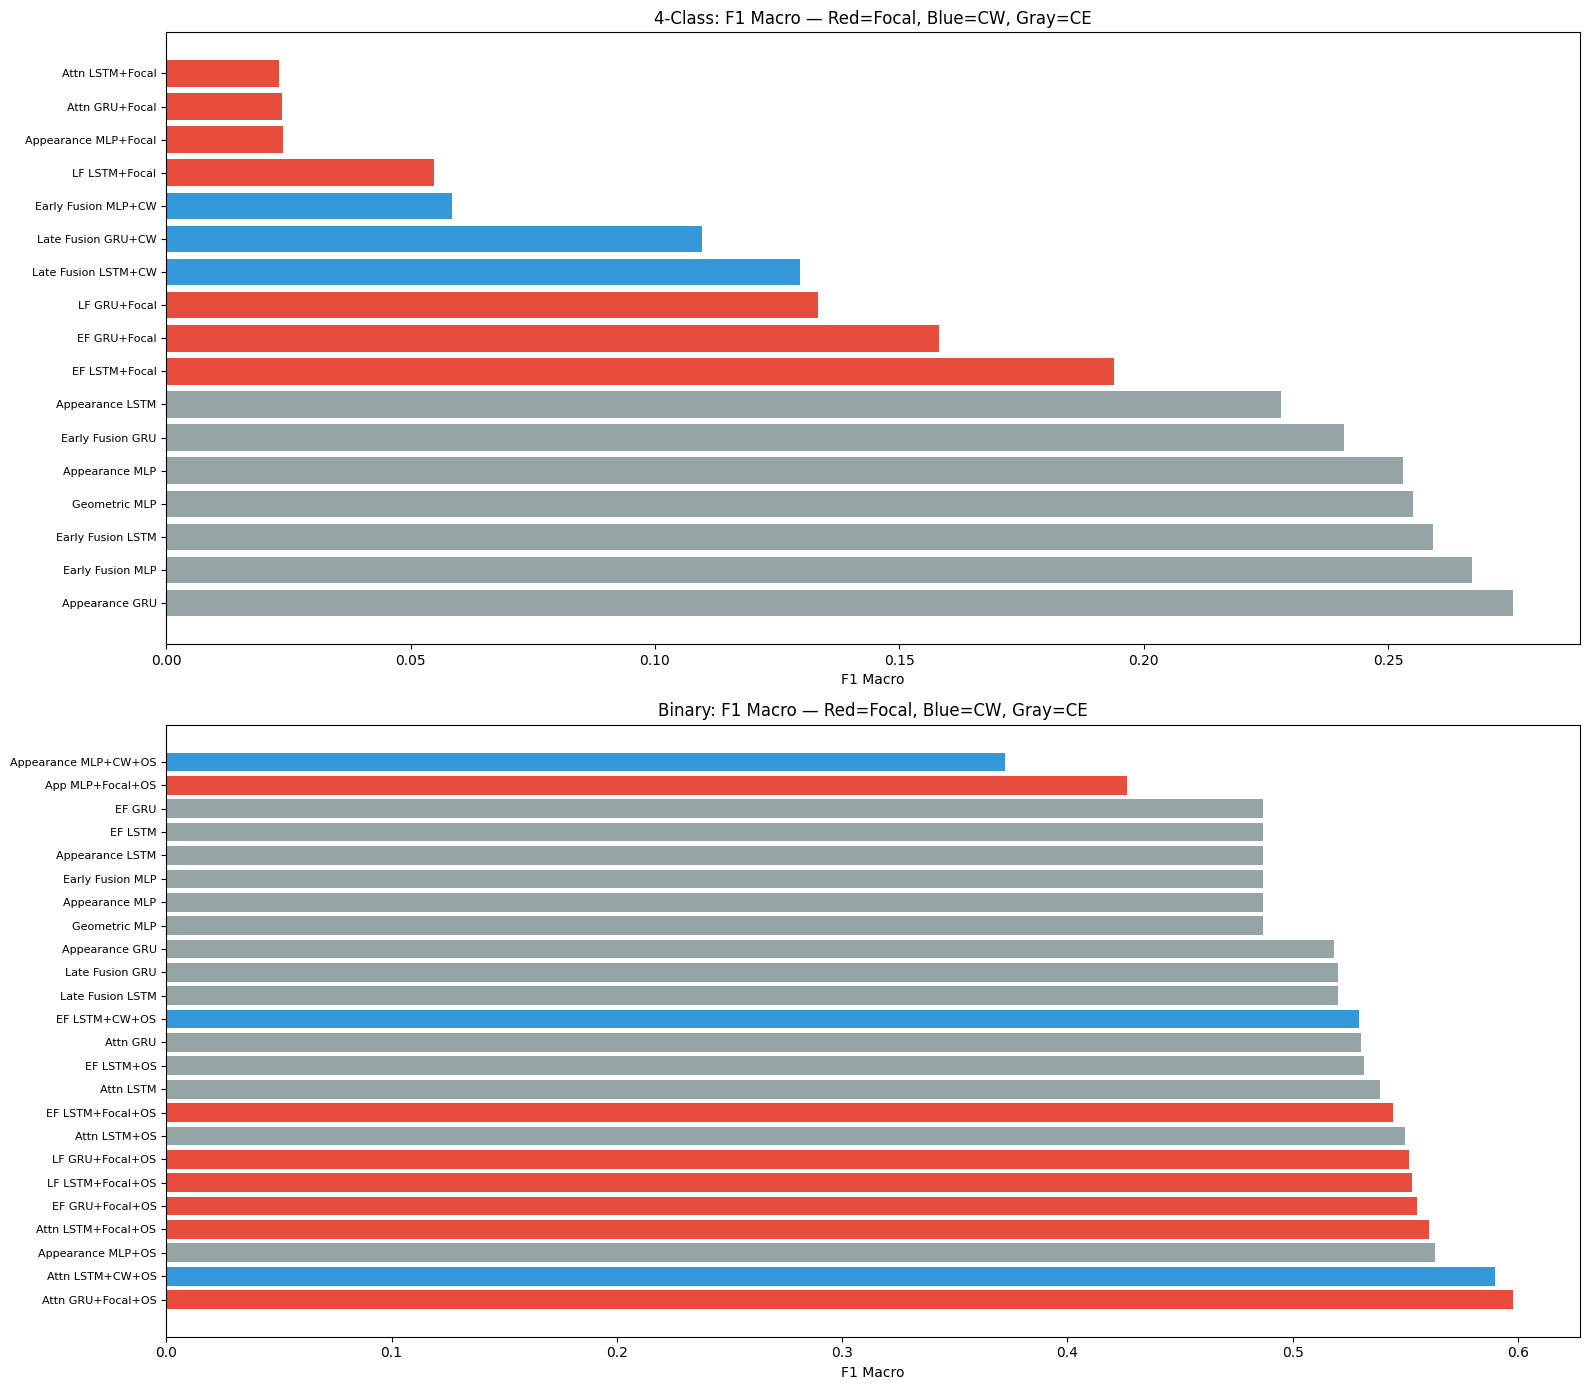

In [ ]:
# --- Bar charts ---
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(16,14))

n4 = sorted(results_4.keys(), key=lambda n:results_4[n]["metrics"]["f1_macro"],reverse=True)
f4 = [results_4[n]["metrics"]["f1_macro"] for n in n4]
c4 = ["#E74C3C" if "Focal" in n else "#3498DB" if "CW" in n else "#95A5A6" for n in n4]
ax1.barh(range(len(n4)),f4,color=c4); ax1.set_yticks(range(len(n4))); ax1.set_yticklabels(n4,fontsize=8)
ax1.set_xlabel("F1 Macro"); ax1.set_title("4-Class: F1 Macro — Red=Focal, Blue=CW, Gray=CE")

n2 = sorted(results_2.keys(), key=lambda n:results_2[n]["metrics"]["f1_macro"],reverse=True)
f2 = [results_2[n]["metrics"]["f1_macro"] for n in n2]
c2 = ["#E74C3C" if "Focal" in n else "#3498DB" if "CW" in n else "#95A5A6" for n in n2]
ax2.barh(range(len(n2)),f2,color=c2); ax2.set_yticks(range(len(n2))); ax2.set_yticklabels(n2,fontsize=8)
ax2.set_xlabel("F1 Macro"); ax2.set_title("Binary: F1 Macro — Red=Focal, Blue=CW, Gray=CE")

plt.tight_layout(); plt.savefig("f1_comparison.png",dpi=150,bbox_inches="tight"); plt.show()

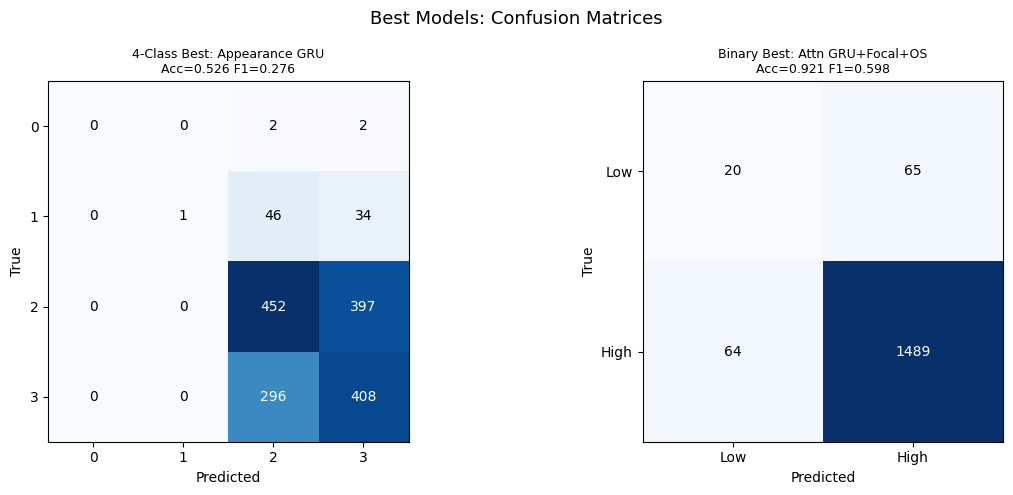

In [ ]:
# --- Best confusion matrices ---
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

b4 = max(results_4, key=lambda n:results_4[n]["metrics"]["f1_macro"])
m4 = results_4[b4]["metrics"]; cm4 = confusion_matrix(m4["labels"],m4["predictions"])
ax1.imshow(cm4,cmap="Blues"); ax1.set_title(f"4-Class Best: {b4}\nAcc={m4['accuracy']:.3f} F1={m4['f1_macro']:.3f}",fontsize=9)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True"); ax1.set_xticks(range(4)); ax1.set_yticks(range(4))
for i in range(4):
    for j in range(4): ax1.text(j,i,str(cm4[i,j]),ha="center",va="center",color="white" if cm4[i,j]>cm4.max()/2 else "black")

b2 = max(results_2, key=lambda n:results_2[n]["metrics"]["f1_macro"])
m2 = results_2[b2]["metrics"]; cm2 = confusion_matrix(m2["labels"],m2["predictions"])
ax2.imshow(cm2,cmap="Blues"); ax2.set_title(f"Binary Best: {b2}\nAcc={m2['accuracy']:.3f} F1={m2['f1_macro']:.3f}",fontsize=9)
ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")
ax2.set_xticks(range(2)); ax2.set_yticks(range(2)); ax2.set_xticklabels(["Low","High"]); ax2.set_yticklabels(["Low","High"])
for i in range(2):
    for j in range(2): ax2.text(j,i,str(cm2[i,j]),ha="center",va="center",color="white" if cm2[i,j]>cm2.max()/2 else "black")

plt.suptitle("Best Models: Confusion Matrices",fontsize=13)
plt.tight_layout(); plt.savefig("best_cm.png",dpi=150,bbox_inches="tight"); plt.show()

In [ ]:
# --- Classification reports ---
print(f"\n{'='*60}\nBest 4-Class: {b4}\n{'='*60}\n{m4['report']}")
print(f"\n{'='*60}\nBest Binary: {b2}\n{'='*60}\n{m2['report']}")


Best 4-Class: Appearance GRU
              precision    recall  f1-score   support

     VeryLow       0.00      0.00      0.00         4
         Low       1.00      0.01      0.02        81
        High       0.57      0.53      0.55       849
    VeryHigh       0.49      0.58      0.53       704

    accuracy                           0.53      1638
   macro avg       0.51      0.28      0.28      1638
weighted avg       0.55      0.53      0.51      1638


Best Binary: Attn GRU+Focal+OS
              precision    recall  f1-score   support

         Low       0.24      0.24      0.24        85
        High       0.96      0.96      0.96      1553

    accuracy                           0.92      1638
   macro avg       0.60      0.60      0.60      1638
weighted avg       0.92      0.92      0.92      1638



 ## 10. LSTM vs GRU Comparison

In [ ]:
print("\n=== LSTM vs GRU: Binary Classification ===")
print(f"{'Config':<25} {'LSTM Acc':>10} {'GRU Acc':>10} {'LSTM F1':>10} {'GRU F1':>10}")
print("-"*70)
pairs = [("Appearance","Appearance LSTM","Appearance GRU"),("Early Fusion","EF LSTM","EF GRU"),
         ("Late Fusion","Late Fusion LSTM","Late Fusion GRU"),("Attention","Attn LSTM","Attn GRU")]
for label,ln,gn in pairs:
    if ln in results_2 and gn in results_2:
        la,ga = results_2[ln]["metrics"]["accuracy"],results_2[gn]["metrics"]["accuracy"]
        lf,gf = results_2[ln]["metrics"]["f1_macro"],results_2[gn]["metrics"]["f1_macro"]
        print(f"{label:<25} {la:>10.4f} {ga:>10.4f} {lf:>10.4f} {gf:>10.4f}")


=== LSTM vs GRU: Binary Classification ===
Config                      LSTM Acc    GRU Acc    LSTM F1     GRU F1
----------------------------------------------------------------------
Appearance                    0.9481     0.9463     0.4867     0.5181
Early Fusion                  0.9481     0.9481     0.4867     0.4867
Late Fusion                   0.9487     0.9487     0.5202     0.5202
Attention                     0.9475     0.9487     0.5386     0.5303
